Number of bins: 100000
Mean firing rate: 2.796666666666667 Hz
Maximum spikes in one 6-ms bin: 3
spk shape: (100000,)

First 30 spike-count bins:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]

spk:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]

hist_input:
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]

Model smooths:
['position', 'self_history']
3rd order deriv of link function is ok!
4th order deriv of link function is ok!
RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =           19     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  1.00031D+05    |proj g|=  9.83220D+04

At iterate    1    f=  3.84692D+04    |proj g|=  3.51165D+04

At iterate    2    f=  2.36388D+04    |proj g|=  1.94240D+04

At iterate    3    f=  1.40563D+04    |proj g|=  8.88263D+03

At iterate    4    f=  9.91324D+03    |proj g|=  4.11643D+03

At iterate    5    f=  7.55901D+03    |proj g|=  1.62415D+03

At it

 This problem is unconstrained.



At iterate    8    f=  4.26090D+03    |proj g|=  3.01392D+02

At iterate    9    f=  4.15972D+03    |proj g|=  3.25217D+02

At iterate   10    f=  4.12349D+03    |proj g|=  9.11662D+01

At iterate   11    f=  4.09928D+03    |proj g|=  1.02230D+02

At iterate   12    f=  4.06905D+03    |proj g|=  8.63177D+01

At iterate   13    f=  4.03399D+03    |proj g|=  4.68701D+01

At iterate   14    f=  4.02100D+03    |proj g|=  5.09519D+01

At iterate   15    f=  4.01226D+03    |proj g|=  3.42470D+01

At iterate   16    f=  4.00811D+03    |proj g|=  2.27255D+01

At iterate   17    f=  4.00446D+03    |proj g|=  1.46149D+01

At iterate   18    f=  4.00297D+03    |proj g|=  8.98314D+00

At iterate   19    f=  4.00135D+03    |proj g|=  2.14227D+01

At iterate   20    f=  3.99946D+03    |proj g|=  1.55327D+01

At iterate   21    f=  3.99914D+03    |proj g|=  1.22750D+02

At iterate   22    f=  3.99638D+03    |proj g|=  1.52904D+01

At iterate   23    f=  3.99596D+03    |proj g|=  8.28720D+00

At iter

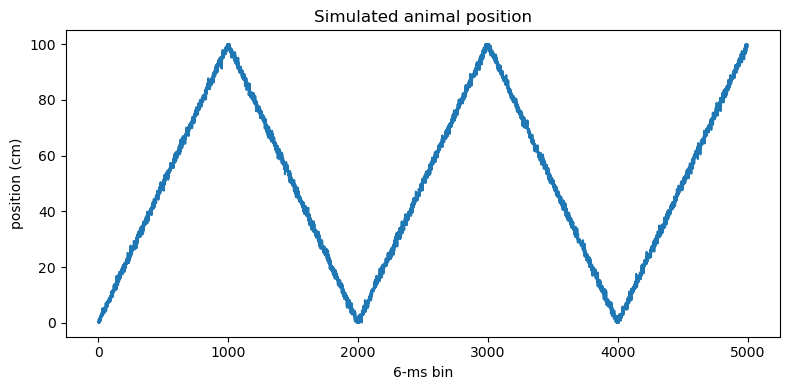

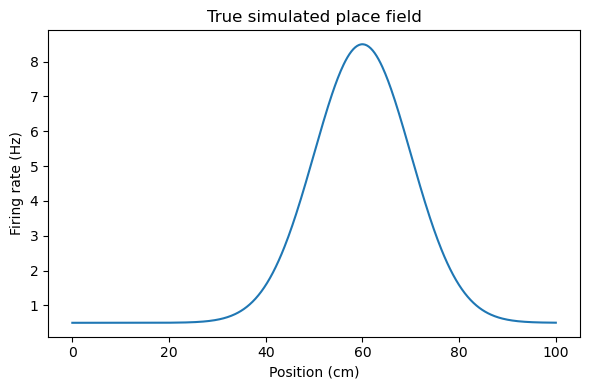

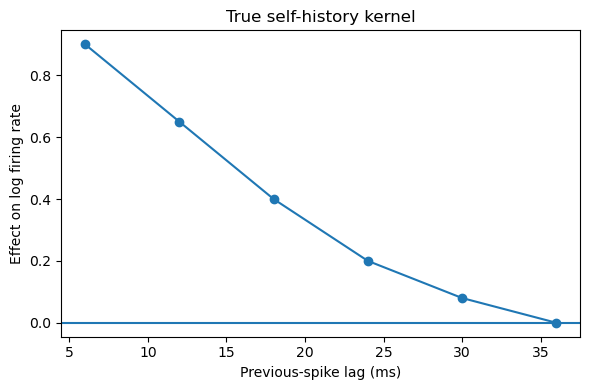

In [5]:

import inspect
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

from PGAM.GAM_library import *
from PGAM.gam_data_handlers import *


# ============================================================
# 1. BASIC PARAMETERS
# ============================================================

rng = np.random.default_rng(42)

dt = 0.006                   # 6 ms bins
duration_sec = 600           # 10 minutes
T = int(duration_sec / dt)

time = np.arange(T) * dt

print("Number of bins:", T)


# ============================================================
# 2. SIMULATE ANIMAL POSITION
#
# Here I use a simple 1-D track from 0 to 100 cm.
# The animal repeatedly runs back and forth.
# ============================================================

track_length = 100.0

period = 12.0                # seconds for one back-and-forth cycle

phase = (time % period) / period

position = np.where(
    phase < 0.5,
    2 * phase * track_length,
    2 * (1 - phase) * track_length
)

# small positional noise
position += rng.normal(0, 1.0, T)

position = np.clip(position, 0, track_length)


# ============================================================
# 3. DEFINE A TRUE PLACE FIELD
# ============================================================

place_center = 60.0          # cm
place_sigma = 10.0           # cm

baseline_rate = 0.5          # Hz
peak_rate = 8.0              # additional Hz in field

place_component = peak_rate * np.exp(
    -(position - place_center)**2 /
    (2 * place_sigma**2)
)

true_rate_without_history = baseline_rate + place_component


# ============================================================
# 4. SIMULATE SPIKES WITH BURSTING
#
# h_true describes how previous spikes affect current firing.
#
# Since dt = 6 ms:
#
# h_true[0] = effect of spike 6 ms ago
# h_true[1] = effect of spike 12 ms ago
# ...
# h_true[5] = effect of spike 36 ms ago
#
# Values are effects on LOG firing rate.
# ============================================================

h_true = np.array([
    0.90,     # 6 ms
    0.65,     # 12 ms
    0.40,     # 18 ms
    0.20,     # 24 ms
    0.08,     # 30 ms
    0.00      # 36 ms
])

n_history_bins = len(h_true)

spk = np.zeros(T, dtype=int)


for t in range(T):

    # Base expected count in this 6-ms bin
    mu_base = true_rate_without_history[t] * dt

    # Start with spatial firing component
    eta = np.log(mu_base)

    # Add effects of PREVIOUS spikes only
    for lag in range(1, n_history_bins + 1):

        if t - lag >= 0:

            eta += (
                h_true[lag - 1]
                * spk[t - lag]
            )

    # convert log expected count back to expected count
    mu = np.exp(eta)

    # safety cap for simulation only, to avoid an accidental
    # runaway self-exciting sequence
    mu = min(mu, 0.75)

    # generate spike count
    spk[t] = rng.poisson(mu)


# ============================================================
# 5. CHECK SIMULATED SPIKES
# ============================================================

mean_rate_hz = spk.sum() / duration_sec

print("Mean firing rate:", mean_rate_hz, "Hz")
print("Maximum spikes in one 6-ms bin:", spk.max())
print("spk shape:", spk.shape)

print("\nFirst 30 spike-count bins:")
print(spk[:30])


# ============================================================
# 6. CONSTRUCT STRICTLY CAUSAL HISTORY INPUT
#
# This is the important part for your real data.
#
# At time t:
#
# response:
#       spk[t]
#
# history predictor:
#       hist_input[t] = spk[t-1]
#
# Therefore the current spike count is NEVER used to predict
# itself.
# ============================================================

hist_input = np.zeros_like(spk, dtype=float)

hist_input[1:] = spk[:-1]


print("\nspk:")
print(spk[:20])

print("\nhist_input:")
print(hist_input[:20])


# Verify causality
assert np.all(
    hist_input[1:] == spk[:-1]
)


# ============================================================
# 7. CREATE PGAM SMOOTH HANDLER
# ============================================================

sm_handler = smooths_handler()


# ============================================================
# 8. ADD POSITION SMOOTH
#
# 1-D place field for this example.
# ============================================================

ord_place = 4

n_place_knots = 12

internal_knots = np.linspace(
    0,
    track_length,
    n_place_knots
)

place_knots = np.hstack((
    [internal_knots[0]] * (ord_place - 1),
    internal_knots,
    [internal_knots[-1]] * (ord_place - 1)
))


sm_handler.add_smooth(
    'position',
    [position],

    ord=4,
    knots=[place_knots],

    is_cyclic=[False],

    penalty_type='der',
    der=2,

    is_temporal_kernel=False,

    lam=10
)


# ============================================================
# 9. ADD SELF-HISTORY SMOOTH
#
# We want approximately:
#
# 6, 12, 18, 24, 30, 36 ms
#
# hist_input has already been shifted by one 6-ms bin.
#
# PGAM now learns a smooth temporal filter applied to
# hist_input.
# ============================================================

kernel_length = 11


sm_handler.add_smooth(
    'self_history',
    [hist_input],

    ord=2,

    # temporal basis complexity
    knots_num=6,

    penalty_type='diff',
    der=2,

    is_temporal_kernel=True,

    # PGAM convention:
    # -1 = post-event causal kernel
    kernel_direction=-1,

    kernel_length=kernel_length,

    # one continuous recording
    trial_idx=np.ones(T, dtype=int),

    time_bin=dt,

    event_input=True,

    lam=10
)


# ============================================================
# 10. CHECK MODEL TERMS
# ============================================================

print("\nModel smooths:")
print(sm_handler.smooths_var)

# should contain:
#
# ['position', 'self_history']


# ============================================================
# 11. DEFINE POISSON MODEL
# ============================================================

link = deriv3_link(
    sm.genmod.families.links.log()
)

poissFam = sm.genmod.families.family.Poisson(
    link=link
)


# ============================================================
# 12. CREATE PGAM MODEL
#
# spk is the RESPONSE.
#
# It also indirectly enters as a predictor through
# hist_input, but hist_input contains only past spikes.
# ============================================================

gam_model = general_additive_model(
    sm_handler,
    sm_handler.smooths_var,
    spk,
    poissFam,
    fisher_scoring=False
)


# ============================================================
# 13. FIT MODEL
# ============================================================

full, reduced = gam_model.fit_full_and_reduced(

    sm_handler.smooths_var,

    th_pval=0.001,

    smooth_pen=None,

    max_iter=1000,

    tol=1e-8,

    conv_criteria='deviance',

    method='L-BFGS-B',

    gcv_sel_tol=1e-13,

    use_dgcv=True,

    fit_initial_beta=True,

    trial_num_vec=np.ones(T)
)


# ============================================================
# 14. PRINT RESULTS
# ============================================================

print("\nFit complete")

print("Terms in full model:")
print(full.var_list)

print("Terms in reduced model:")
print(reduced.var_list)


# ============================================================
# 15. PLOT THE SIMULATED PLACE FIELD
# ============================================================

plt.figure(figsize=(8, 4))

plt.plot(
    position[:5000],
    label='position'
)

plt.xlabel("6-ms bin")
plt.ylabel("position (cm)")
plt.title("Simulated animal position")
plt.tight_layout()
plt.show()


# ============================================================
# 16. PLOT TRUE SPATIAL FIRING RATE
# ============================================================

xx = np.linspace(0, track_length, 500)

true_place_rate = (
    baseline_rate
    +
    peak_rate * np.exp(
        -(xx - place_center)**2 /
        (2 * place_sigma**2)
    )
)

plt.figure(figsize=(6, 4))

plt.plot(
    xx,
    true_place_rate
)

plt.xlabel("Position (cm)")
plt.ylabel("Firing rate (Hz)")
plt.title("True simulated place field")
plt.tight_layout()
plt.show()


# ============================================================
# 17. SHOW TRUE HISTORY KERNEL USED FOR SIMULATION
# ============================================================

lags_ms = np.arange(
    1,
    n_history_bins + 1
) * dt * 1000

plt.figure(figsize=(6, 4))

plt.plot(
    lags_ms,
    h_true,
    marker='o'
)

plt.axhline(0)

plt.xlabel("Previous-spike lag (ms)")
plt.ylabel("Effect on log firing rate")
plt.title("True self-history kernel")
plt.tight_layout()
plt.show()